<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Analytika úspěchu zákazníků</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Analýza kořenových příčin odchodu zákazníků</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">Diagram příčin a následků PROC FISHBONE pro revizi retence B2B SaaS středního segmentu</div>
</div>

## Shrnutí

Tato analýza uspořádává hlavní kořenové příčiny zvýšeného odchodu zákazníků SaaS do
strukturovaného diagramu příčin a následků (Ishikawa). Segment B2B středního trhu odchází
zhruba 18 % ročně oproti cíli 8 %. Dvacet kořenových zjištění — čerpaných z výstupních
průzkumů, rozhovorů s týmem Customer Success a atribuce kohort — je seskupeno do šesti
kategorií příčin a vykresleno pomocí `PROC FISHBONE` jako diagram s 27 uzly (jeden následek,
šest kategoriových větví, dvacet dílčích příčin).

Podpůrný rozklad `PROC MEANS` ukazuje, kde se přisouditelný odchod koncentruje. **Produkt**
nese nejvíce zjištění (5 příčin, 48,1 celkových bodů dopadu), následován **cenami** (4
příčiny, 42,3) a **podporou** (4 příčiny, 40,2). Měřeno průměrným dopadem *na příčinu* je
nejzávažnější kategorií **konkurence** (průměr 11,8) a jednotlivě nejvyšší dopad ze všech má
zjištění v kategorii **ceny** — zvýšení ceny při obnovení bez předchozího upozornění (14,2).
Pohled Pareto z `PROC SGPLOT` seřadí každou jednotlivou příčinu, aby vedení vidělo, na které
větve reagovat nejdříve. Výstup slouží čtvrtletní revizi retence týmu Customer Success.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.CHURN_RCA | Kořenová zjištění odchodu zákazníků konsolidovaná z analýzy výstupních průzkumů a retrospektivy týmu CS; každý řádek je jedna příčina s kategorií, podpůrným důkazem a odhadovaným podílem na dopadu odchodu | 20 |

---

In [1]:
/* --------------------------------------------------------
   Customer churn root-cause findings (RCA)
   SaaS platform, B2B mid-market segment.
   Each row: cause category, the specific cause, a
   supporting subcause/evidence note, and the estimated
   share of churn attributable to it (from exit-survey
   and cohort attribution).
   -------------------------------------------------------- */
data work.churn_rca;
    DÉLKA category $20 cause $110 subcause $130;
    INFILE DATALINES dlm='|' dsd truncover;
    VSTUP category :$20. cause :$110. subcause :$130. churn_impact_pct;
    DATALINES;
Produkt|Mezery v základních funkcích oproti podnikovým konkurentům|Hromadný export a limity API zmíněny v 34 % výstupních průzkumů|12.4
Produkt|Omezené možnosti reportingu|V standardním tarifu chybí tvorba vlastních dashboardů|9.8
Produkt|Mobilní aplikace zaostává za webovou funkčností|3 klíčové úkony nemohou dokončit uživatelé pouze na mobilu|8.2
Produkt|Časté změny UI bez upozornění|Čtvrtletní redesigny narušují práci pokročilých uživatelů|7.6
Produkt|Mezery v integračním marketplace|Chybí nativní konektory pro Salesforce a HubSpot|10.1
Ceny|Zvýšení ceny při obnovení bez předchozího upozornění|Zvýšení MRR o 18 % s 30denním oznámením|14.2
Ceny|Model za uživatele penalizuje růst týmu|Cena se zdvojnásobí při růstu týmu z 10 na 20|11.3
Ceny|Úvodní sleva není obnovitelná|Šok z ceny při první obnově|9.7
Ceny|Chybí pobídka pro víceletou smlouvu|Roční cena je stejná jako měsíční|7.1
Podpora|Doba první reakce přesahuje 24 hodin|Cílová hodnota tarifu je 4 hodiny|10.8
Podpora|Slabší kvalita podpory o víkendu|Zahraniční pokrytí postrádá znalost produktu|9.3
Podpora|Chybí vyhrazený CSM pod úrovní Enterprise|Zákazníci ze středního segmentu nemají jmenovaný kontakt|11.5
Podpora|Nejasná eskalační cesta pro zákazníky|38 % odchozích účtů uvedlo zmatek ohledně eskalace|8.6
Onboarding|Doba do dosažení hodnoty přesahuje 90 dní|Složitost implementace nebyla sdělena před prodejem|12.9
Onboarding|Zastaralá samoobslužná dokumentace|Naposledy aktualizováno před 11 měsíci|8.1
Onboarding|Chybí prohlídky novými funkcemi v aplikaci|Adopce funkcí pod 30 % po 6 měsících|9.4
Konkurence|Konkurent nabízí o 30 % nižší cenu|Tři významné účty uvedly konkrétního konkurenta|13.1
Konkurence|Konkurent nabízí neomezený počet uživatelů v ceně|Odstraňuje penalizaci za uživatele pro rostoucí týmy|10.6
Vztahy|Nezvládnutá fluktuace výkonného sponzora|Zastánce odešel; chybí program opětovného zapojení|11.7
Vztahy|Frekvence QBR snížena na roční|Snížení kapacity CS týmu před 18 měsíci|9.2
;
SPUSTIT;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: churn impact concentration by RCA category.
   Sum shows where attributable churn clusters; max flags
   the single worst cause in each category.
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.churn_rca n sum mean MAX maxdec=1;
    TŘÍDA category;
    PROMĚNNÁ churn_impact_pct;
    ŠTÍTEK category='Kategorie' churn_impact_pct='Podíl na dopadu odchodu (%)';
    NÁZEV 'Analýza kořenových příčin odchodu zákazníků: podíl dopadu podle kategorie';
SPUSTIT;

                       Analýza kořenových příčin odchodu zákazníků: podíl dopadu podle kategorie                        

                                                  The MEANS Procedure

                           Analysis Variable : churn_impact_pct Podíl na dopadu odchodu (%)

        Kategorie           N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------
        Ceny                    4           42.3           10.6           14.2
        Konkurence              2           23.7           11.8           13.1
        Onboarding              3           30.4           10.1           12.9
        Podpora                 4           40.2           10.1           11.5
        Produkt                 5           48.1            9.6           12.4
        Vztahy                  2           20.9           10.4           11.7
        ----------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                       Analýza kořenových příčin odchodu zákazníků: podíl dopadu podle kategorie                        




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


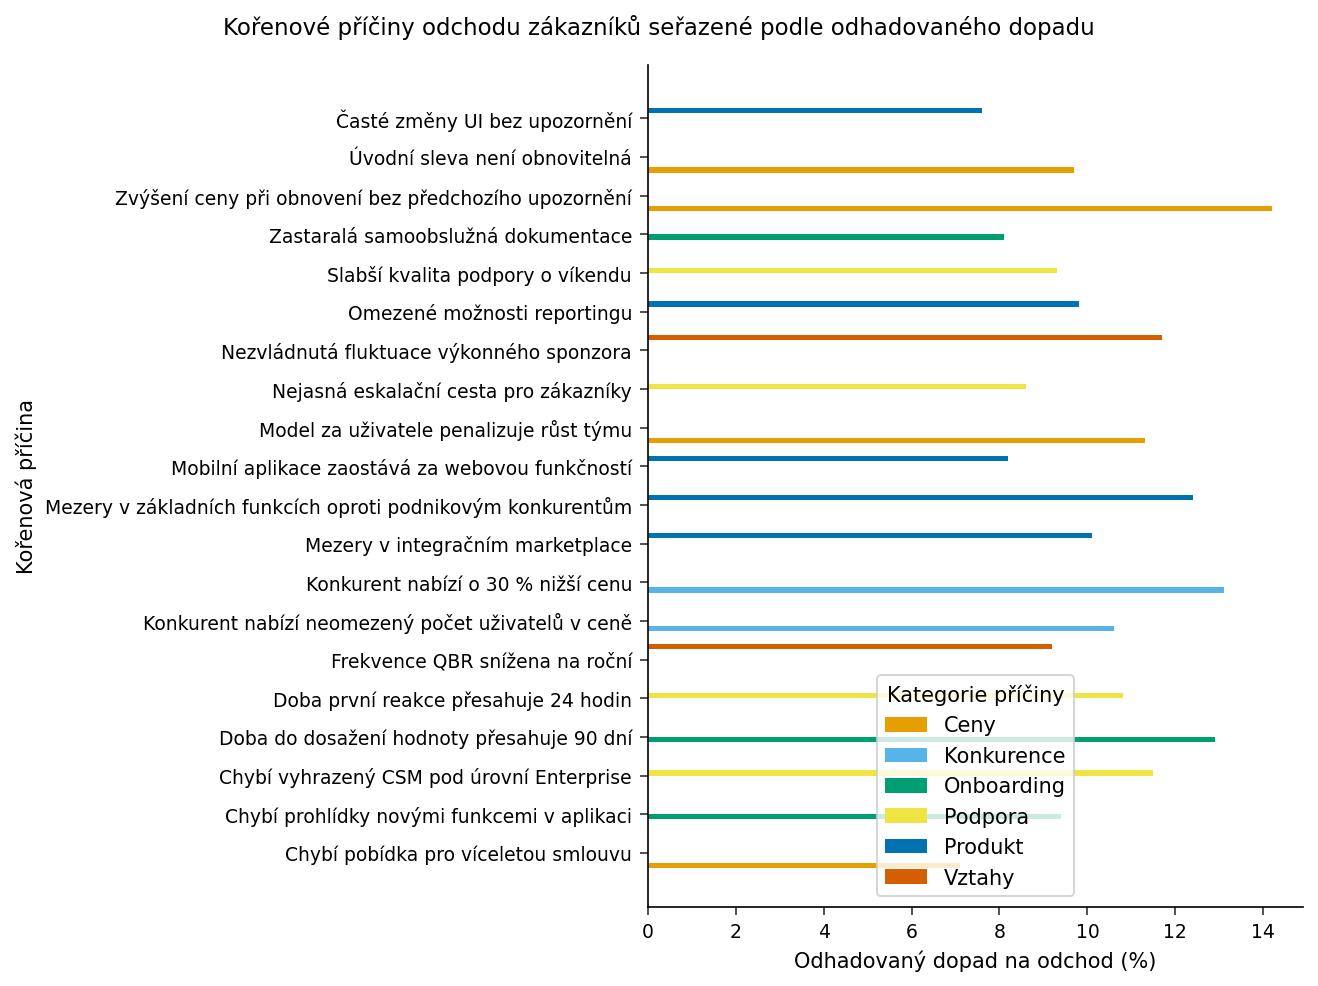

In [3]:
/* --------------------------------------------------------
   Pareto view: individual root causes ranked by estimated
   churn impact, colored by category. This complements the
   fishbone by quantifying which bones matter most.
   -------------------------------------------------------- */
PROCEDURA ŘADIT data=work.churn_rca;
    PODLE SESTUPNĚ churn_impact_pct;
SPUSTIT;

PROCEDURA SGPLOT data=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='Odhadovaný dopad na odchod (%)';
    YAXIS label='Kořenová příčina' discreteorder=data;
    keylegend / title='Kategorie příčiny' position=bottom;
    NÁZEV 'Kořenové příčiny odchodu zákazníků seřazené podle odhadovaného dopadu';
SPUSTIT;

---

### Diagram příčin a následků (Ishikawa)

`PROC FISHBONE` sestavuje diagram přímo z `WORK.CHURN_RCA`: každá odlišná `category` se
stává hlavní větví vycházející z centrální osy a jednotlivá zjištění `cause` visí na své
kategoriové větvi jako dílčí příčiny. Procedura níže vytiskne úplnou strukturu příčin a
následků — následek v čele, šest kategoriových větví a každou dílčí příčinu seskupenou pod
svou větví — a zapíše odpovídající grafiku rybí kosti na disk. Výše uvedený seřazený Pareto
graf je doplňkový pohled, který kvantifikuje, která z těchto větví nese nejvíce
přisouditelného odchodu.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: customer churn cause-and-effect diagram.
   The diagram is driven directly from WORK.CHURN_RCA, so
   the six cause categories and their causes are exactly
   the findings analyzed above. CATEGORY forms the major
   bones; CAUSE hangs as sub-causes off each bone.
   -------------------------------------------------------- */
PROCEDURA fishbone data=work.churn_rca;
    cause category / subcause=cause;
    effect 'Zvýšený odchod zákazníků (18 % ročně oproti cíli 8 %)';
    NÁZEV 'Analýza kořenových příčin odchodu zákazníků - segment středního trhu';
    footnote 'Zdroje: výstupní průzkumy, rozhovory s týmem CS, atribuce kohort';
SPUSTIT;

                       Analýza kořenových příčin odchodu zákazníků: podíl dopadu podle kategorie                        


                    Analýza kořenových příčin odchodu zákazníků - segment středního trhu
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Zvýšený odchod zákazníků (18 % ročně oproti cíli 8 %)
    [CAUSE] Ceny (top)
      [SUB] Zvýšení ceny při obnovení bez předchozího upozornění
      [SUB] Model za uživatele penalizuje růst týmu
      [SUB] Úvodní sleva není obnovitelná
      [SUB] Chybí pobídka pro víceletou smlouvu
    [CAUSE] Konkurence (top)
      [SUB] Konkurent nabízí o 30 % nižší cenu
      [SUB] Konkurent nabízí neomezený počet uživatelů v ceně
    [CAUSE] Onboarding (top)
      [SUB] Doba do dosažení hodnoty přesahuje 90 dní
      [SUB] Chybí prohlídky novými funkcemi v aplikaci
      [SUB] Zastaralá samoobslužná dokumentace
    [CAUSE] Produkt (bottom)
      [SUB] Mezery v základních funkcích oproti podnikovým konkurentů


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretace

Struktura příčin a následků společně s údaji `PROC MEANS` za jednotlivé kategorie ukazují
vedení malý počet zásahů s velkým dopadem. Dvě nejvyšší jednotlivá zjištění — zvýšení ceny
při obnovení bez upozornění v kategorii **ceny** (14,2) a zjištění v kategorii **konkurence**,
že konkurent prodává srovnatelnou funkčnost o 30 % levněji (13,1) — jsou obě obchodní, nikoli
produktové povahy, což naznačuje, že cenová transparentnost a konkurenční pozicování jsou
nejnaléhavější krátkodobé páky. Zjištění v kategorii **onboarding** — doba do dosažení
hodnoty přesahující 90 dní (12,9) — je největším zjištěním na straně služeb a přímo souvisí
s nastavením očekávání před prodejem.

Objemově dominuje diagramu **produkt** (5 z 20 zjištění, 48,1 celkových bodů dopadu), ale
jeho zjištění jsou jednotlivě menší (průměr 9,6) než v kategorii **konkurence** (průměr 11,8)
nebo **ceny** (průměr 10,6) — připomínka, že dlouhý seznam produktových mezer automaticky
neznamená nejvyšší prioritu. Větev **vztahy** (fluktuace výkonného sponzora a snížená
frekvence QBR, dohromady 20,9) představuje procesní změny, které tým CS může zavést v rámci
současného čtvrtletí bez investic do produktu nebo cen, a nabízí tak nejrychlejší cestu k
měřitelnému zlepšení retence. Úplný seřazený seznam v Pareto grafu umožňuje vedení seřadit
zásahy podle odhadovaného dopadu, nikoli podle velikosti kategorie.

---

In [5]:
/* --------------------------------------------------------
   Export churn RCA findings for strategy review deck
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno nástrojem <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>